Factor relative performance:
Categorical features

In [2]:
# Import libraries:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [3]:
import os
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

In [4]:
df_factors = pd.read_csv("factor_returns.csv", parse_dates=['Date'])
df_factors = df_factors.set_index('Date')

In [5]:
# --- Data Upload ---
def load_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

file_path = ('factor_benchmark_returns.csv')
df=load_data(file_path)

# Ensure data type is: float
print(df.dtypes)

Momentum      float64
Value         float64
Quality       float64
Benchmarks    float64
dtype: object


In [6]:
# --- Relative Returns Calculation ---
def relative_returns(df):
    for factor in ['Momentum', 'Value', 'Quality']:
        df[f'{factor}_Relative'] = df[factor] - df['Benchmarks']
    return df

df_rel_returns = relative_returns(df)
print(df_rel_returns)

            Momentum   Value  Quality  Benchmarks  Momentum_Relative  \
Date                                                                   
2004-01-01    0.0103  0.0316      NaN    0.037828          -0.027528   
2004-02-01    0.0157  0.0102      NaN   -0.001956           0.017656   
2004-03-01    0.0147  0.0139      NaN    0.003079           0.011621   
2004-04-01   -0.0227  0.0068      NaN   -0.017248          -0.005452   
2004-05-01    0.0018  0.0034      NaN    0.005029          -0.003229   
...              ...     ...      ...         ...                ...   
2025-01-01   -0.0233  0.0083   0.0044    0.025600          -0.048900   
2025-02-01    0.0066 -0.0067  -0.0240   -0.003800           0.010400   
2025-03-01    0.0816  0.0228   0.0336    0.036100           0.045500   
2025-04-01    0.0581  0.0557   0.0425    0.042700           0.015400   
2025-05-01    0.0246  0.0193   0.0274    0.030400          -0.005800   

            Value_Relative  Quality_Relative  
Date            

In [7]:
# --- Relative Performance Between Factors ---
def factor_relative_returns(df, factors=None):

    if factors is None:
        factors = ['Momentum', 'Value', 'Quality']
    
    # Calculate all pairwise relative returns
    for i, factor1 in enumerate(factors):
        for j, factor2 in enumerate(factors):
            if i < j:  # Avoid duplicates and self-comparisons
                rel_col = f'{factor1}_vs_{factor2}'
                df[rel_col] = df[factor1] - df[factor2]
    
    return df

# Usage
df_factor_rel = factor_relative_returns(df.copy())
print(df_factor_rel)

            Momentum   Value  Quality  Benchmarks  Momentum_Relative  \
Date                                                                   
2004-01-01    0.0103  0.0316      NaN    0.037828          -0.027528   
2004-02-01    0.0157  0.0102      NaN   -0.001956           0.017656   
2004-03-01    0.0147  0.0139      NaN    0.003079           0.011621   
2004-04-01   -0.0227  0.0068      NaN   -0.017248          -0.005452   
2004-05-01    0.0018  0.0034      NaN    0.005029          -0.003229   
...              ...     ...      ...         ...                ...   
2025-01-01   -0.0233  0.0083   0.0044    0.025600          -0.048900   
2025-02-01    0.0066 -0.0067  -0.0240   -0.003800           0.010400   
2025-03-01    0.0816  0.0228   0.0336    0.036100           0.045500   
2025-04-01    0.0581  0.0557   0.0425    0.042700           0.015400   
2025-05-01    0.0246  0.0193   0.0274    0.030400          -0.005800   

            Value_Relative  Quality_Relative  Momentum_vs_Value

In [8]:
# --- Cumulative Relative Returns Calculation ---
factors = ['Momentum_vs_Value', 'Momentum_vs_Quality', 'Value_vs_Quality']
def cumulative_relative_returns(df):
    for factor in factors:
        # Calculate cumulative product of (1 + relative return)
        cumulative_returns = (1 + df[factor]).cumprod() - 1
        df[f'{factor}_Cumulative'] = cumulative_returns
    return df

# Apply the function to your dataframe
df_cumulative = cumulative_relative_returns(df_factor_rel.copy())
print(df_cumulative)

            Momentum   Value  Quality  Benchmarks  Momentum_Relative  \
Date                                                                   
2004-01-01    0.0103  0.0316      NaN    0.037828          -0.027528   
2004-02-01    0.0157  0.0102      NaN   -0.001956           0.017656   
2004-03-01    0.0147  0.0139      NaN    0.003079           0.011621   
2004-04-01   -0.0227  0.0068      NaN   -0.017248          -0.005452   
2004-05-01    0.0018  0.0034      NaN    0.005029          -0.003229   
...              ...     ...      ...         ...                ...   
2025-01-01   -0.0233  0.0083   0.0044    0.025600          -0.048900   
2025-02-01    0.0066 -0.0067  -0.0240   -0.003800           0.010400   
2025-03-01    0.0816  0.0228   0.0336    0.036100           0.045500   
2025-04-01    0.0581  0.0557   0.0425    0.042700           0.015400   
2025-05-01    0.0246  0.0193   0.0274    0.030400          -0.005800   

            Value_Relative  Quality_Relative  Momentum_vs_Value

In [12]:
# --- Trend Scanning Functions ---
def tval_lin(close):

    # Computes t-values on sample determined by look-forward window L
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sm.OLS(close, x).fit()
    return ols.tvalues[1]

def get_bins(molecule, close, span):
    # Pick the value of L that maximizes t-values

    out = pd.DataFrame(index=molecule, columns=['t1', 'tval', 'bin'])
    hrzns = range(*span)
    
    for dt0 in molecule:
        df0 = pd.Series(dtype=float)
        iloc0 = close.index.get_loc(dt0)
        
        if iloc0 + max(hrzns) > len(close):
            continue
            
        for hrzn in hrzns:
            dt1 = close.index[iloc0 + hrzn - 1]
            df1 = close.loc[dt0:dt1]
            df0.loc[dt1] = tval_lin(df1.values)
            
        if not df0.empty:
            dt1 = df0.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
            tval = df0[dt1]
            
            # Create binary label based on t-value significance and sign
            if abs(tval) >= 0:
                bin_label = 1 if tval > 0 else 0  # 1=up, 0=down
            else:
                bin_label = np.nan  # Not significant, will be dropped
                
            out.loc[dt0, ['t1', 'tval', 'bin']] = dt1, tval, bin_label


    out['t1'] = pd.to_datetime(out['t1'])
    out['bin'] = pd.to_numeric(out['bin'], downcast='signed')
    return out.dropna(subset=['bin'])

In [13]:
# --- Execute with Debugging ---
if __name__ == "__main__":
    # Load data
    file_path = 'factor_benchmark_returns.csv'
    df = load_data(file_path)
    
    # Calculate returns
    df = factor_relative_returns(df)
    df = cumulative_relative_returns(df)
    
    # Apply trend scanning to each factor
    span = (1, 12)
    
    # Fixed factor list (no duplicates)
    factors_to_scan = ['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']
    
    for factor in factors_to_scan:
        col_name = f'{factor}_Cumulative'
        if col_name not in df.columns:
            print(f"Warning: Column '{col_name}' not found. Skipping {factor}.")
            continue

        print(f"\nProcessing {factor}...")
        print(f"Data shape: {df[col_name].shape}")
        print(f"NaN values: {df[col_name].isna().sum()}")
        
        # Get trend labels with error handling
        try:
            trend_labels = get_bins(df.index, df[col_name], span)
            
            # Check if trend_labels is None
            if trend_labels is None:
                print(f"Error: get_bins() returned None for {factor}")
                continue
                
            print(f"Trend labels shape: {trend_labels.shape}")
            print(f"Trend labels index type: {type(trend_labels.index)}")
            
            # Ensure proper index alignment
            if not df.index.equals(trend_labels.index):
                print("Index mismatch - reindexing trend labels...")
                trend_labels = trend_labels.reindex(df.index)
            
            # Merge labels back to original DataFrame
            label_col_name = f'{factor}_trend'
            df[label_col_name] = trend_labels['bin']  # Only take the 'bin' column if that's what you want
            
            print(f"Successfully added trend labels for {factor}")
            print(f"Non-NaN trend values: {df[label_col_name].notna().sum()}")
            
        except Exception as e:
            print(f"Error processing {factor}: {e}")
            import traceback
            traceback.print_exc()
    
    # Save results
    df.to_csv('labeled_relative_factor_returns.csv')
    print("\nLabeled data saved to 'labeled_relative_factor_returns.csv'")


Processing Momentum_vs_Value...
Data shape: (257,)
NaN values: 0
Trend labels shape: (247, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Momentum_vs_Value
Non-NaN trend values: 247

Processing Value_vs_Quality...
Data shape: (257,)
NaN values: 37
Trend labels shape: (210, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Value_vs_Quality
Non-NaN trend values: 210

Processing Momentum_vs_Quality...
Data shape: (257,)
NaN values: 37
Trend labels shape: (210, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Momentum_vs_Quality
Non-NaN trend values: 210

Labeled data saved to 'labeled_relative_factor_returns.csv'


In [14]:
print(df.columns)

Index(['Momentum', 'Value', 'Quality', 'Benchmarks', 'Momentum_vs_Value',
       'Momentum_vs_Quality', 'Value_vs_Quality',
       'Momentum_vs_Value_Cumulative', 'Momentum_vs_Quality_Cumulative',
       'Value_vs_Quality_Cumulative', 'Momentum_vs_Value_trend',
       'Value_vs_Quality_trend', 'Momentum_vs_Quality_trend'],
      dtype='object')


Simple Trend Scanning Visualization


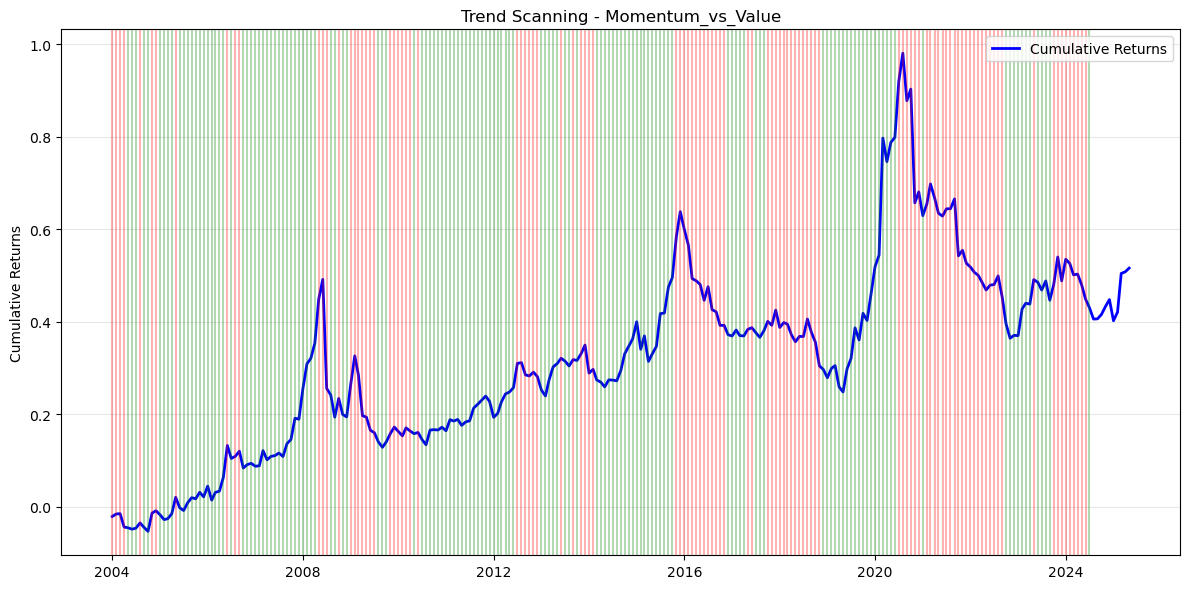

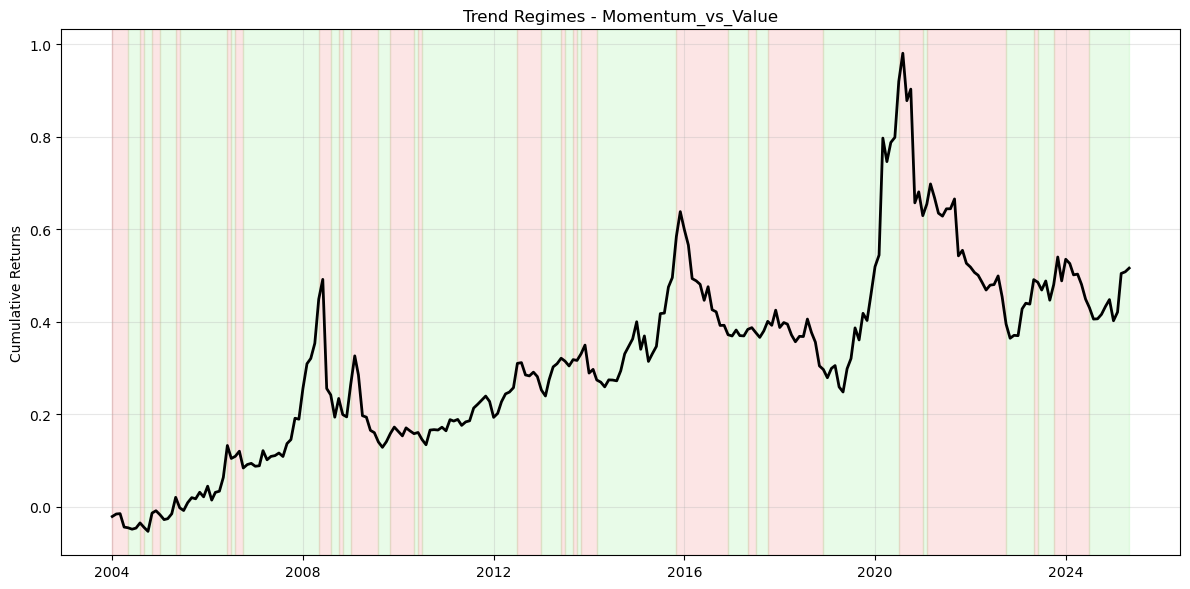

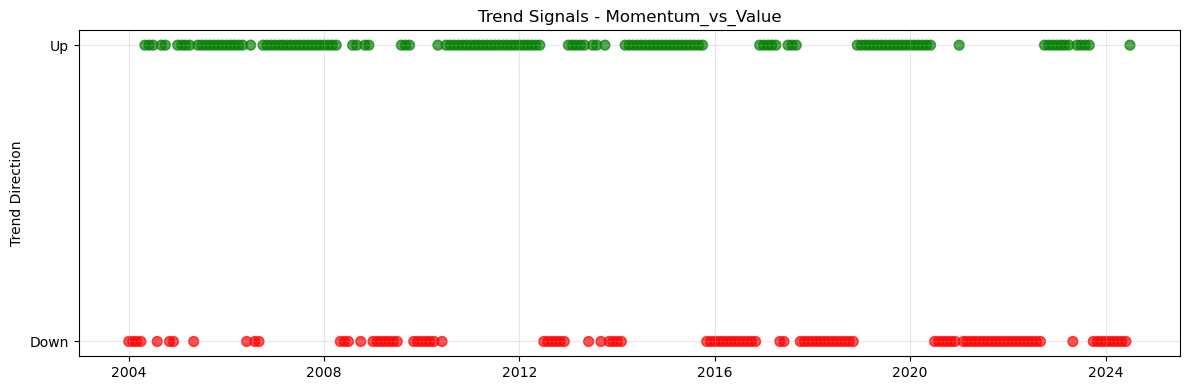

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Simple Trend Scanning Visualization
def plot_simple_trend_scanning(df, factor):
    """
    Simple plot of cumulative returns with trend signals
    """
    cum_col = f'{factor}_Cumulative'
    trend_col = f'{factor}_trend'
    
    # Create figure
    plt.figure(figsize=(12, 6))
    
    # Plot cumulative returns
    plt.plot(df.index, df[cum_col], 'b-', linewidth=2, label='Cumulative Returns')
    
    # Add trend signals
    valid_trends = df[trend_col].dropna()
    for date, trend in valid_trends.items():
        color = 'green' if trend == 1 else 'red'
        plt.axvline(x=date, color=color, alpha=0.3, linestyle='-')
    
    plt.title(f'Trend Scanning - {factor}')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Basic Cumulative Returns with Trend Background
def plot_trend_background(df, factor):
    """
    Plot with colored background for trend regimes
    """
    cum_col = f'{factor}_Cumulative'
    trend_col = f'{factor}_trend'
    
    plt.figure(figsize=(12, 6))
    
    # Plot cumulative returns
    plt.plot(df.index, df[cum_col], 'black', linewidth=2, label='Cumulative Returns')
    
    # Add colored background for trends
    trend_changes = df[trend_col].dropna().diff().fillna(1) != 0
    change_points = trend_changes[trend_changes].index
    
    start_date = df.index[0]
    for end_date in change_points:
        if start_date in df.index and not pd.isna(df.loc[start_date, trend_col]):
            trend_val = df.loc[start_date, trend_col]
            color = 'lightgreen' if trend_val == 1 else 'lightcoral'
            plt.axvspan(start_date, end_date, alpha=0.2, color=color)
        start_date = end_date
    
    # Final segment
    if start_date in df.index and not pd.isna(df.loc[start_date, trend_col]):
        trend_val = df.loc[start_date, trend_col]
        color = 'lightgreen' if trend_val == 1 else 'lightcoral'
        plt.axvspan(start_date, df.index[-1], alpha=0.2, color=color)
    
    plt.title(f'Trend Regimes - {factor}')
    plt.ylabel('Cumulative Returns')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Trend Signal Scatter Plot
def plot_trend_signals(df, factor):
    """
    Simple scatter plot of trend signals
    """
    trend_col = f'{factor}_trend'
    
    plt.figure(figsize=(12, 4))
    
    valid_trends = df[trend_col].dropna()
    colors = ['green' if x == 1 else 'red' for x in valid_trends]
    
    plt.scatter(valid_trends.index, valid_trends, c=colors, s=50, alpha=0.7)
    plt.title(f'Trend Signals - {factor}')
    plt.yticks([0, 1], ['Down', 'Up'])
    plt.ylabel('Trend Direction')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usage Example
if __name__ == "__main__":
    # Load your data (replace with your actual data loading)
    df = pd.read_csv('labeled_relative_factor_returns.csv', index_col=0, parse_dates=True)
    
    # Example usage with dummy data
    print("Simple Trend Scanning Visualization")
    
    # Choose which factor to plot
    factor_to_plot = 'Momentum_vs_Value'  # Change this to your factor
    
    # Plot the charts
    plot_simple_trend_scanning(df, factor_to_plot)
    plot_trend_background(df, factor_to_plot)
    plot_trend_signals(df, factor_to_plot)

Plotting trend signals with triangles...


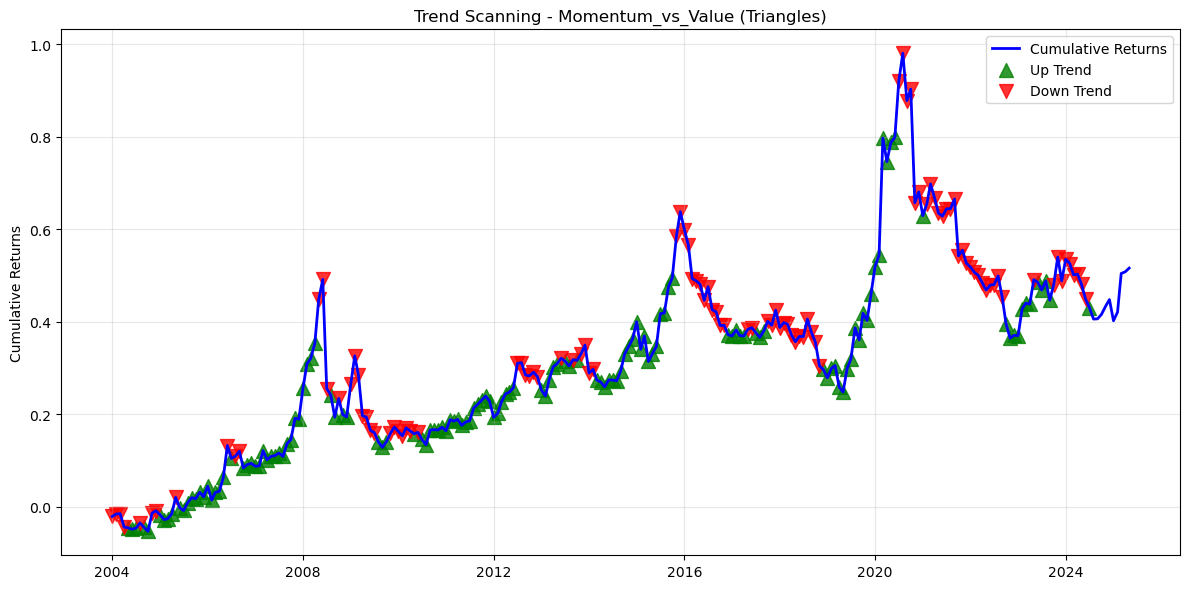

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Simple Trend Scanning Visualization with Triangles
def plot_trend_triangles(df, factor):
    """
    Plot cumulative returns with triangle markers for trend signals
    """
    cum_col = f'{factor}_Cumulative'
    trend_col = f'{factor}_trend'
    
    # Create figure
    plt.figure(figsize=(12, 6))
    
    # Plot cumulative returns
    plt.plot(df.index, df[cum_col], 'b-', linewidth=2, label='Cumulative Returns')
    
    # Add trend signals as triangles
    valid_trends = df[trend_col].dropna()
    
    # Up trends (green upward triangles)
    up_trends = valid_trends[valid_trends == 1]
    if not up_trends.empty:
        plt.scatter(up_trends.index, df.loc[up_trends.index, cum_col], 
                   color='green', marker='^', s=100, label='Up Trend', alpha=0.8)
    
    # Down trends (red downward triangles)
    down_trends = valid_trends[valid_trends == 0]
    if not down_trends.empty:
        plt.scatter(down_trends.index, df.loc[down_trends.index, cum_col], 
                   color='red', marker='v', s=100, label='Down Trend', alpha=0.8)
    
    plt.title(f'Trend Scanning - {factor} (Triangles)')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Dual Plot with Triangles and Background
def plot_trend_combo(df, factor):
    """
    Combined plot with background colors and triangle markers
    """
    cum_col = f'{factor}_Cumulative'
    trend_col = f'{factor}_trend'
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Top: Cumulative returns with triangles
    ax1.plot(df.index, df[cum_col], 'black', linewidth=2, label='Cumulative Returns')
    
    # Add trend triangles
    valid_trends = df[trend_col].dropna()
    up_mask = valid_trends == 1
    down_mask = valid_trends == 0
    
    if any(up_mask):
        ax1.scatter(valid_trends[up_mask].index, df.loc[valid_trends[up_mask].index, cum_col],
                   color='green', marker='^', s=80, label='Up Signal', alpha=0.8)
    
    if any(down_mask):
        ax1.scatter(valid_trends[down_mask].index, df.loc[valid_trends[down_mask].index, cum_col],
                   color='red', marker='v', s=80, label='Down Signal', alpha=0.8)
    
    ax1.set_ylabel('Cumulative Returns')
    ax1.set_title(f'Trend Signals - {factor}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Bottom: Trend signals as triangles on separate axis
    ax2.scatter(valid_trends.index, valid_trends, 
               c=['green' if x==1 else 'red' for x in valid_trends],
               marker=['^' if x==1 else 'v' for x in valid_trends], 
               s=60, alpha=0.7)
    
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Down', 'Up'])
    ax2.set_ylabel('Trend Direction')
    ax2.set_xlabel('Date')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Minimal Triangle Plot
def min_triangle_plot(df, factor):
    """
    Minimal plot with only triangles on cumulative returns
    """
    cum_col = f'{factor}_Cumulative'
    trend_col = f'{factor}_trend'
    
    plt.figure(figsize=(12, 5))
    
    # Plot cumulative returns
    plt.plot(df.index, df[cum_col], 'blue', linewidth=1.5, alpha=0.7)
    
    # Add trend triangles directly on the line
    trends = df[trend_col].dropna()
    
    for date, trend in trends.items():
        y_value = df.loc[date, cum_col]
        if trend == 1:
            plt.plot(date, y_value, 'g^', markersize=8, alpha=0.8)
        else:
            plt.plot(date, y_value, 'rv', markersize=8, alpha=0.8)
    
    plt.title(f'{factor} - Cumulative Returns with Trend Triangles')
    plt.ylabel('Cumulative Returns')
    plt.grid(True, alpha=0.3)
    plt.show()

# Advanced Triangle Plot with Size Variation
def advanced_triangle_plot(df, factor):
    """
    Advanced plot with triangle size based on t-value strength
    """
    cum_col = f'{factor}_Cumulative'
    trend_col = f'{factor}_trend'
    tval_col = f'{factor}_tval'  # Assuming you have t-values stored
    
    plt.figure(figsize=(14, 6))
    
    # Plot cumulative returns
    plt.plot(df.index, df[cum_col], 'navy', linewidth=2, alpha=0.8, label='Cumulative Returns')
    
    # Add trend triangles with size based on t-value magnitude
    valid_trends = df[trend_col].dropna()
    
    if tval_col in df.columns:
        # Size based on absolute t-value (capped for visibility)
        sizes = np.minimum(np.abs(df.loc[valid_trends.index, tval_col]) * 20, 200)
    else:
        sizes = 80  # Default size if no t-values
    
    up_mask = valid_trends == 1
    down_mask = valid_trends == 0
    
    if any(up_mask):
        up_dates = valid_trends[up_mask].index
        plt.scatter(up_dates, df.loc[up_dates, cum_col],
                   s=sizes[up_mask] if tval_col in df.columns else 80,
                   color='limegreen', marker='^', alpha=0.7,
                   edgecolors='darkgreen', linewidth=1,
                   label='Up Trend (size = t-value strength)')
    
    if any(down_mask):
        down_dates = valid_trends[down_mask].index
        plt.scatter(down_dates, df.loc[down_dates, cum_col],
                   s=sizes[down_mask] if tval_col in df.columns else 80,
                   color='lightcoral', marker='v', alpha=0.7,
                   edgecolors='darkred', linewidth=1,
                   label='Down Trend (size = t-value strength)')
    
    plt.title(f'Advanced Trend Analysis - {factor}')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usage Example
if __name__ == "__main__":
    # Load your data (replace with your actual data loading)
    # df = pd.read_csv('labeled_relative_factor_returns.csv', index_col=0, parse_dates=True)
    
    # Choose which factor to plot
    factor_to_plot = 'Momentum_vs_Value'  # Change this to your factor
    
    # Plot the different triangle versions
    print("Plotting trend signals with triangles...")
    
    # Simple triangle plot
    plot_trend_triangles(df, factor_to_plot)
    
    # Combined plot
    #plot_trend_combo(df, factor_to_plot)
    
    # Minimal plot
    #min_triangle_plot(df, factor_to_plot)
    
    # Advanced plot (if you have t-values)
    if f'{factor_to_plot}_tval' in df.columns:
        advanced_triangle_plot(df, factor_to_plot)

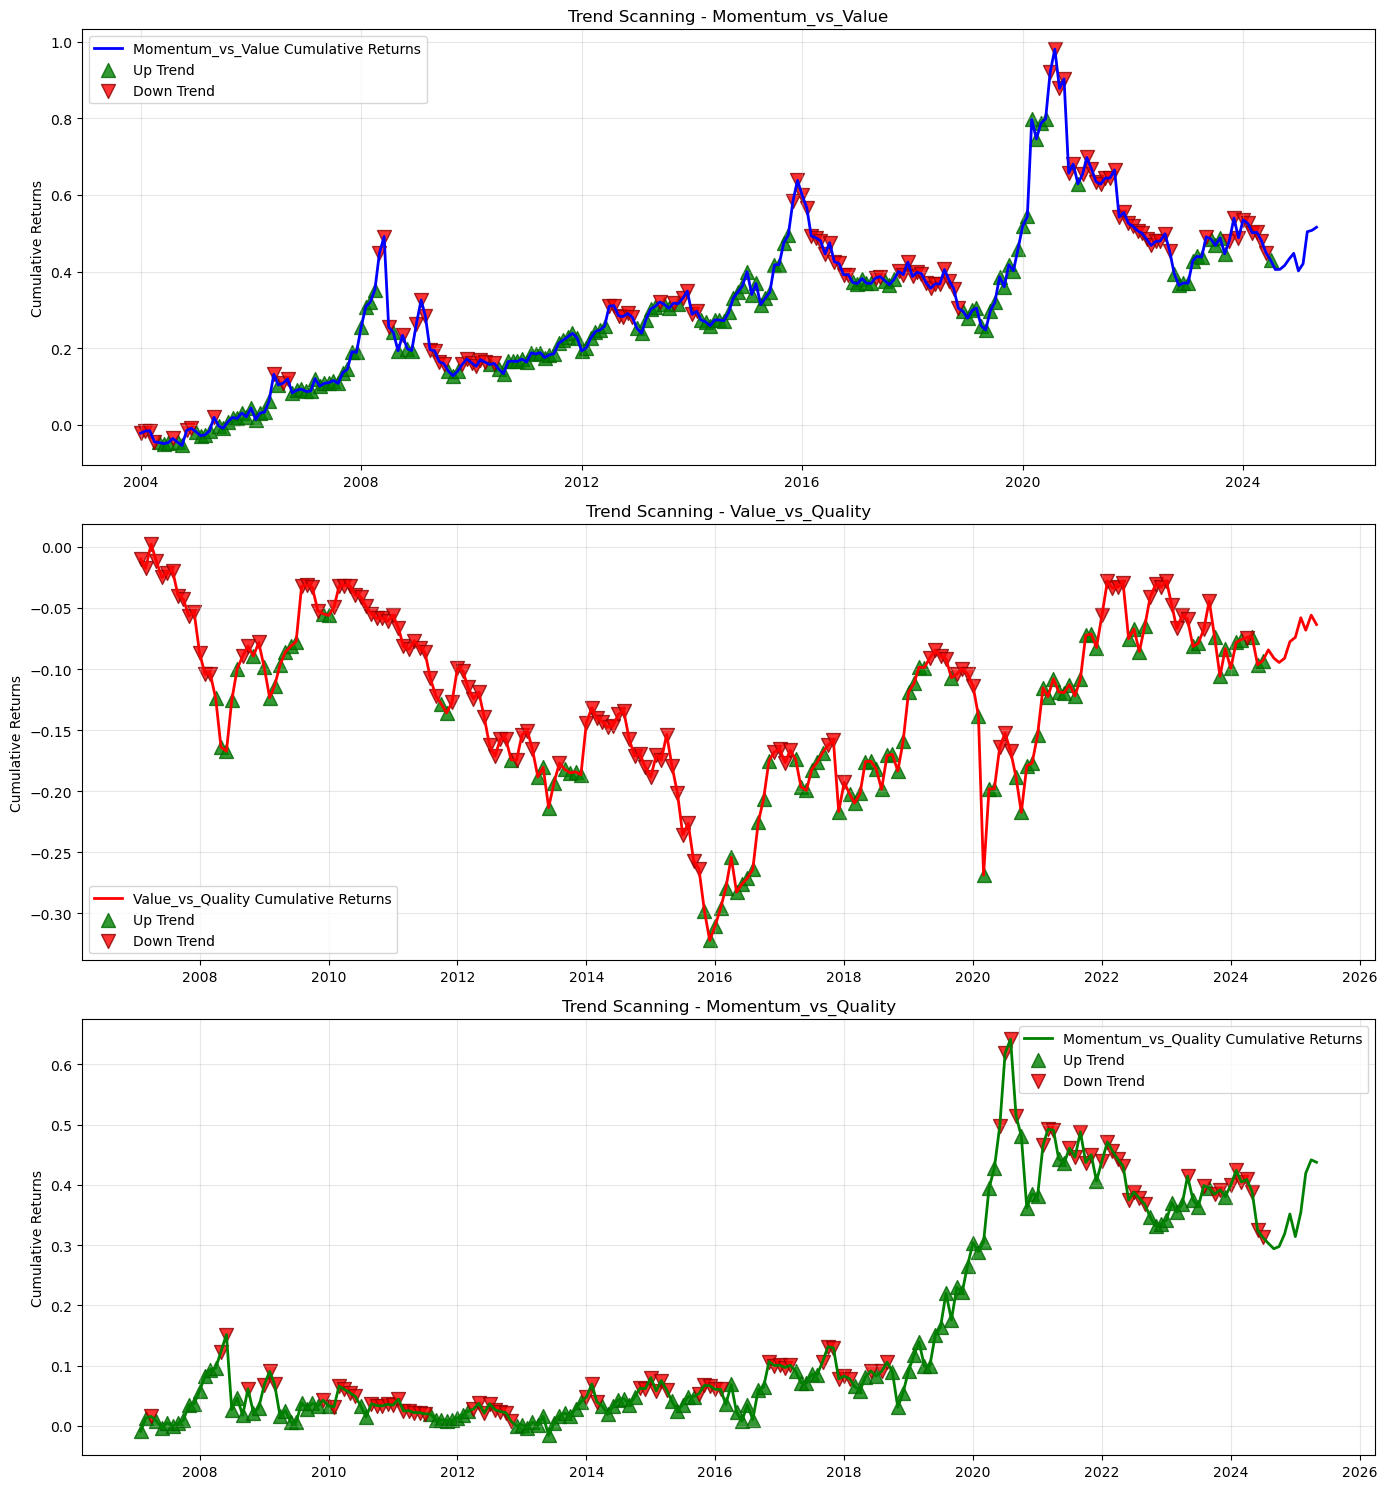

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_trend_triangles(df, factors):
    """
    Plot cumulative returns with triangle markers for trend signals for multiple factors
    """
    # Create subplots for each factor
    n_factors = len(factors)
    fig, axes = plt.subplots(n_factors, 1, figsize=(14, 5 * n_factors))
    
    # If only one factor, make axes a list for consistent indexing
    if n_factors == 1:
        axes = [axes]
    
    # Colors for different factors
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, factor in enumerate(factors):
        cum_col = f'{factor}_Cumulative'
        trend_col = f'{factor}_trend'
        
        if cum_col not in df.columns or trend_col not in df.columns:
            print(f"Warning: Columns for {factor} not found. Skipping.")
            continue
        
        ax = axes[i]
        
        # Plot cumulative returns
        ax.plot(df.index, df[cum_col], color=colors[i % len(colors)], 
                linewidth=2, label=f'{factor} Cumulative Returns')
        
        # Add trend signals as triangles
        valid_trends = df[trend_col].dropna()
        
        # Up trends (green upward triangles)
        up_trends = valid_trends[valid_trends == 1]
        if not up_trends.empty:
            ax.scatter(up_trends.index, df.loc[up_trends.index, cum_col], 
                      color='green', marker='^', s=100, label='Up Trend', alpha=0.8,
                      edgecolors='darkgreen', linewidth=1)
        
        # Down trends (red downward triangles)
        down_trends = valid_trends[valid_trends == 0]
        if not down_trends.empty:
            ax.scatter(down_trends.index, df.loc[down_trends.index, cum_col], 
                      color='red', marker='v', s=100, label='Down Trend', alpha=0.8,
                      edgecolors='darkred', linewidth=1)
        
        ax.set_title(f'Trend Scanning - {factor}')
        ax.set_ylabel('Cumulative Returns')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Usage
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('labeled_relative_factor_returns.csv', index_col=0, parse_dates=True)
    
    # Define which factors to plot
    factors_to_plot = ['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']
    
    # Plot all factors
    plot_trend_triangles(df, factors_to_plot)